In [14]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

sys.path.append(str(Path().resolve().parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
from hyperparameters.hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [20]:
DATA_DIR = Path("../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [15]:
def create_baseline_model():
    model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], 
                        kernel_sizes = [3, 3, 3], fc_layers = [128, 64], num_classes = 10)
    return model

def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_alexnet_model():
    model = ModifiedAlexNet(num_classes=10).to(device)
    return model

def get_stratified_indices(dataset, ratio, seed):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)
    
    generator = torch.Generator().manual_seed(seed)
    selected_indices = []
    
    for label, indices in class_indices.items():
        n_samples = int(ratio * len(indices))
        perm = torch.randperm(len(indices), generator=generator)
        selected = [indices[i] for i in perm[:n_samples]]
        selected_indices.extend(selected)
    
    return selected_indices

def test_reduced_dataset(model, train_loader, valid_loader, test_loader, training_ratios,
                         seeds, scheduler=None, device=None, num_epochs=20):
    

    results = {}
    full_train_ds = train_loader.dataset
    batch_size = train_loader.batch_size

    for ratio in training_ratios:
        results[ratio] = {}
        for seed in seeds:
            print(f"\nTRAINING RATIO={ratio} | SEED={seed}")
            set_seed(seed)

            if ratio < 1.0:
                indices = get_stratified_indices(full_train_ds, ratio, seed)
                train_subset = Subset(full_train_ds, indices)
            else:
                train_subset = full_train_ds

            subset_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        
            model_instance = model()
            model_instance = model_instance.to(device)
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)
            
            print("------------------------------------------------------")
            history = train(model_instance, subset_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=num_epochs, verbose=True, verbose_interval=max(1, int(num_epochs / 10)))
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss     = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)
            
            results[ratio][seed] = {
                "history":    history,
                "valid_acc":  validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc":   test_accuracy,
                "test_loss":  test_loss
            }
            
            print("------------------------------------------------------")
            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")
            print("------------------------------------------------------")
    
    return results

In [16]:
TRAINING_RATIOS = [0.1, 0.25, 0.5, 0.75, 1.0]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [21]:
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

#### Baseline model

In [23]:
baseline_results = test_reduced_dataset(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, training_ratios=TRAINING_RATIOS, seeds=SEEDS, num_epochs=20, device=device)


TRAINING RATIO=0.1 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.6904 | Valid Loss: 1.6884 | Valid Acc: 0.3507
Epoch 4/20 | Train Loss: 1.5144 | Valid Loss: 1.5075 | Valid Acc: 0.4324
Epoch 6/20 | Train Loss: 1.4186 | Valid Loss: 1.4853 | Valid Acc: 0.4500
Epoch 8/20 | Train Loss: 1.3037 | Valid Loss: 1.9146 | Valid Acc: 0.3781
Epoch 10/20 | Train Loss: 1.2410 | Valid Loss: 1.7747 | Valid Acc: 0.4041
Epoch 12/20 | Train Loss: 1.1440 | Valid Loss: 1.5157 | Valid Acc: 0.4589
Epoch 14/20 | Train Loss: 1.0733 | Valid Loss: 1.8493 | Valid Acc: 0.4048
Epoch 16/20 | Train Loss: 0.9726 | Valid Loss: 1.8202 | Valid Acc: 0.4321
Epoch 18/20 | Train Loss: 0.9147 | Valid Loss: 1.6704 | Valid Acc: 0.4721
Epoch 20/20 | Train Loss: 0.8540 | Valid Loss: 2.3824 | Valid Acc: 0.3382
Best validation accuracy: 0.4788
------------------------------------------------------
VALIDATION ACCURACY: 0.3382 | TEST ACCURACY: 0.3389
----------------------------------------

In [24]:
save_results(baseline_results, 'results_baseline.json')

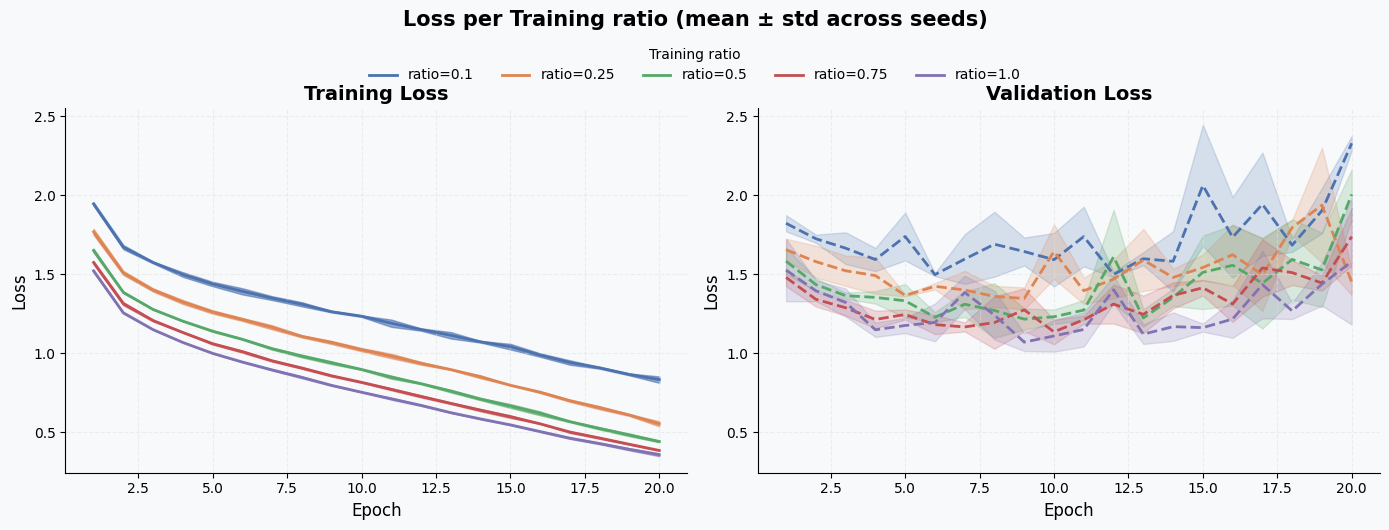

In [40]:
plot_loss_comparison(baseline_results, param_name="Training ratio", param_name_short = 'ratio')

In [41]:
for param, seed_dict in baseline_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.1 | seeds=3 | max std=0.022963
lr=0.25 | seeds=3 | max std=0.019073
lr=0.5 | seeds=3 | max std=0.012182
lr=0.75 | seeds=3 | max std=0.009662
lr=1.0 | seeds=3 | max std=0.009218


In [42]:
df = summarize_results(baseline_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.10,0.375200,0.027022,2.328782,0.045948,0.374178,0.026074,2.334831,0.042838
1,Model,0.25,0.558248,0.008054,1.450318,0.081646,0.554944,0.008589,1.467224,0.082867
2,Model,0.50,0.517756,0.022422,2.005226,0.158734,0.516544,0.022540,2.020480,0.155792
3,Model,0.75,0.571630,0.023010,1.738135,0.182423,0.569004,0.022741,1.753696,0.182511
4,Model,1.00,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124


In [43]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.10,0.3752 ± 0.0270,2.3288 ± 0.0459,0.3742 ± 0.0261,2.3348 ± 0.0428
1,Model,0.25,0.5582 ± 0.0081,1.4503 ± 0.0816,0.5549 ± 0.0086,1.4672 ± 0.0829
2,Model,0.50,0.5178 ± 0.0224,2.0052 ± 0.1587,0.5165 ± 0.0225,2.0205 ± 0.1558
3,Model,0.75,0.5716 ± 0.0230,1.7381 ± 0.1824,0.5690 ± 0.0227,1.7537 ± 0.1825
4,Model,1.00,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021


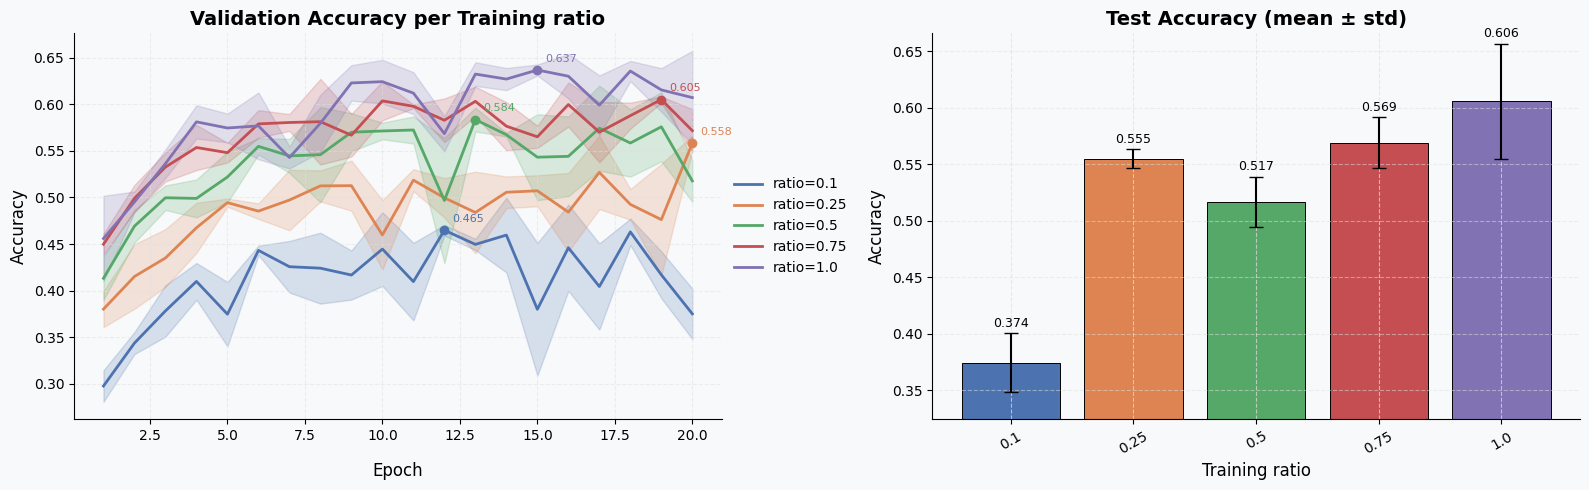

In [44]:
plot_accuracy_comparison(baseline_results, param_name="Training ratio", param_name_short = 'ratio')

#### Alexnet

In [25]:
alexnet_results = test_reduced_dataset(model=create_alexnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, training_ratios=TRAINING_RATIOS, seeds=SEEDS, num_epochs=20, device=device)


TRAINING RATIO=0.1 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.7629 | Valid Loss: 1.7588 | Valid Acc: 0.3192
Epoch 4/20 | Train Loss: 1.5463 | Valid Loss: 1.7831 | Valid Acc: 0.3506
Epoch 6/20 | Train Loss: 1.4283 | Valid Loss: 1.6335 | Valid Acc: 0.4070
Epoch 8/20 | Train Loss: 1.3306 | Valid Loss: 1.5020 | Valid Acc: 0.4599
Epoch 10/20 | Train Loss: 1.1989 | Valid Loss: 1.3596 | Valid Acc: 0.5047
Epoch 12/20 | Train Loss: 1.1206 | Valid Loss: 1.6692 | Valid Acc: 0.4365
Epoch 14/20 | Train Loss: 1.0324 | Valid Loss: 1.6532 | Valid Acc: 0.4711
Epoch 16/20 | Train Loss: 0.9091 | Valid Loss: 1.7009 | Valid Acc: 0.4676
Epoch 18/20 | Train Loss: 0.8098 | Valid Loss: 2.0268 | Valid Acc: 0.4667
Epoch 20/20 | Train Loss: 0.7162 | Valid Loss: 1.4933 | Valid Acc: 0.5423
Best validation accuracy: 0.5423
------------------------------------------------------
VALIDATION ACCURACY: 0.5423 | TEST ACCURACY: 0.5407
----------------------------------------

In [26]:
save_results(alexnet_results, 'results_alexnet.json')

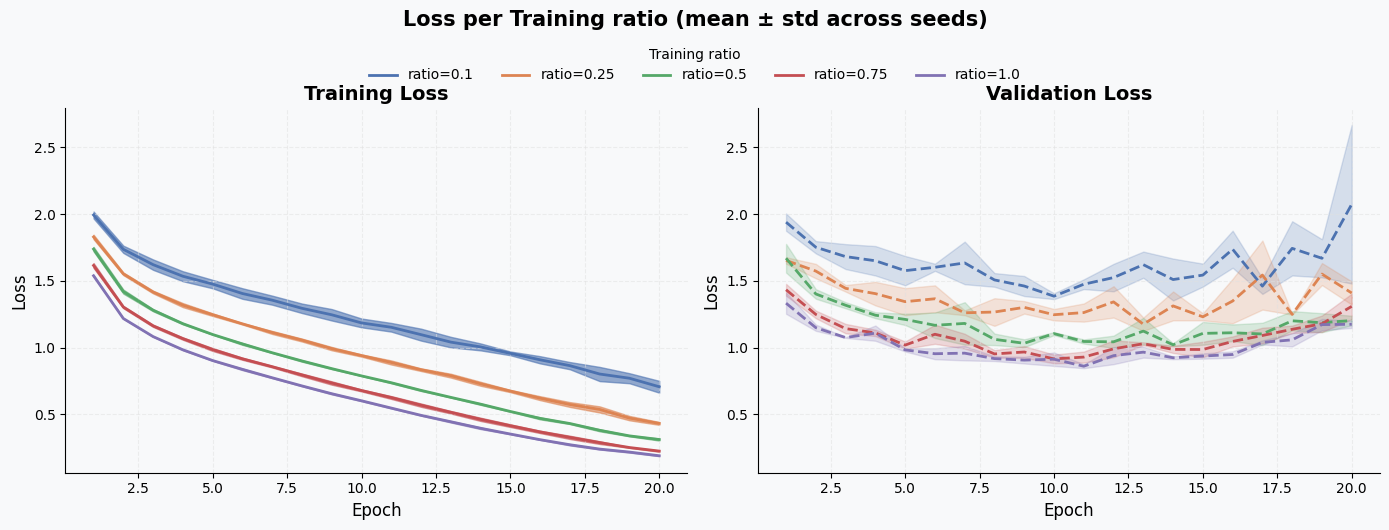

In [35]:
plot_loss_comparison(alexnet_results, param_name="Training ratio", param_name_short = 'ratio')

In [36]:
for param, seed_dict in alexnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.1 | seeds=3 | max std=0.053163
lr=0.25 | seeds=3 | max std=0.022890
lr=0.5 | seeds=3 | max std=0.016109
lr=0.75 | seeds=3 | max std=0.017612
lr=1.0 | seeds=3 | max std=0.006092


In [37]:
df = summarize_results(alexnet_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.10,0.459244,0.078672,2.073237,0.594308,0.459419,0.078258,2.087270,0.602577
1,Model,0.25,0.600493,0.014490,1.408229,0.086749,0.599026,0.014691,1.422603,0.088059
2,Model,0.50,0.674511,0.006376,1.202200,0.035869,0.671948,0.007411,1.224191,0.038789
3,Model,0.75,0.685819,0.012279,1.308193,0.095079,0.681637,0.011089,1.333196,0.093052
4,Model,1.00,0.717526,0.011017,1.174095,0.027310,0.716563,0.011439,1.185701,0.027313


In [38]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.10,0.4592 ± 0.0787,2.0732 ± 0.5943,0.4594 ± 0.0783,2.0873 ± 0.6026
1,Model,0.25,0.6005 ± 0.0145,1.4082 ± 0.0867,0.5990 ± 0.0147,1.4226 ± 0.0881
2,Model,0.50,0.6745 ± 0.0064,1.2022 ± 0.0359,0.6719 ± 0.0074,1.2242 ± 0.0388
3,Model,0.75,0.6858 ± 0.0123,1.3082 ± 0.0951,0.6816 ± 0.0111,1.3332 ± 0.0931
4,Model,1.00,0.7175 ± 0.0110,1.1741 ± 0.0273,0.7166 ± 0.0114,1.1857 ± 0.0273


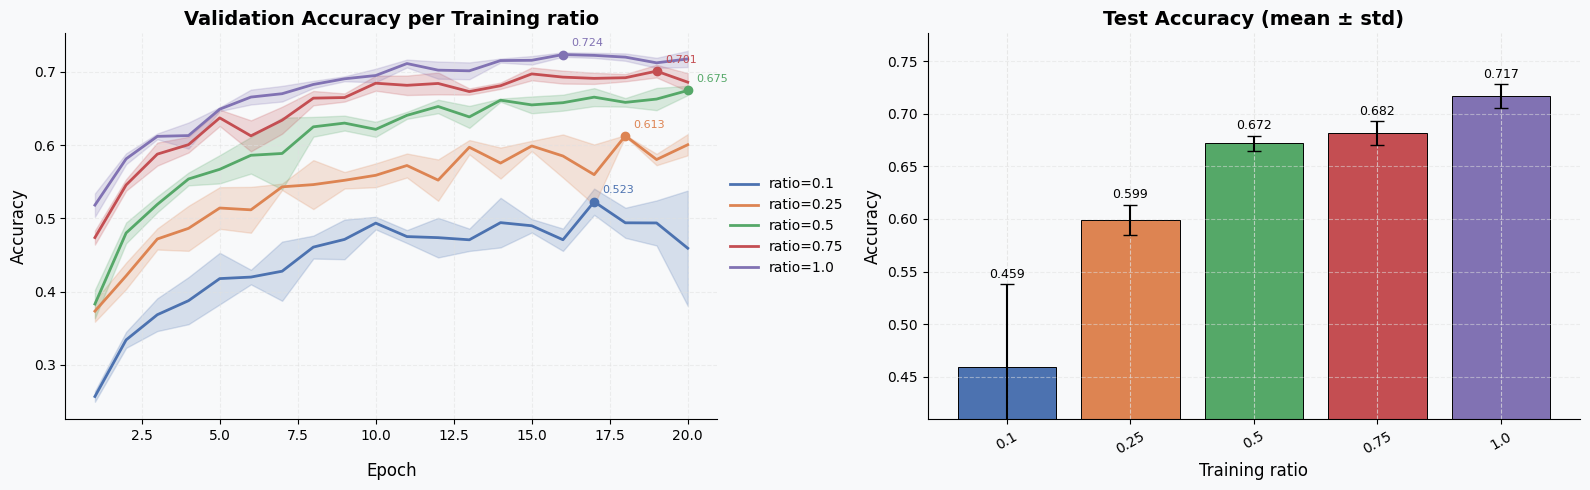

In [39]:
plot_accuracy_comparison(alexnet_results, param_name="Training ratio", param_name_short = 'ratio')

#### Resnet

In [27]:
resnet_results = test_reduced_dataset(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, training_ratios=TRAINING_RATIOS, seeds=SEEDS, num_epochs=20, device=device)


TRAINING RATIO=0.1 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.6207 | Valid Loss: 1.7535 | Valid Acc: 0.3655
Epoch 4/20 | Train Loss: 1.2796 | Valid Loss: 1.7863 | Valid Acc: 0.3978
Epoch 6/20 | Train Loss: 0.9446 | Valid Loss: 1.9094 | Valid Acc: 0.3988
Epoch 8/20 | Train Loss: 0.6190 | Valid Loss: 2.2797 | Valid Acc: 0.3831
Epoch 10/20 | Train Loss: 0.3836 | Valid Loss: 2.6479 | Valid Acc: 0.3943
Epoch 12/20 | Train Loss: 0.3179 | Valid Loss: 2.7563 | Valid Acc: 0.3911
Epoch 14/20 | Train Loss: 0.2204 | Valid Loss: 2.9361 | Valid Acc: 0.3850
Epoch 16/20 | Train Loss: 0.1053 | Valid Loss: 3.5027 | Valid Acc: 0.3969
Epoch 18/20 | Train Loss: 0.1529 | Valid Loss: 3.0070 | Valid Acc: 0.4173
Epoch 20/20 | Train Loss: 0.0818 | Valid Loss: 3.3355 | Valid Acc: 0.4077
Best validation accuracy: 0.4209
------------------------------------------------------
VALIDATION ACCURACY: 0.4077 | TEST ACCURACY: 0.4078
----------------------------------------

In [29]:
save_results(resnet_results, 'results_resnet.json')

In [ ]:
plot_loss_comparison(resnet_results, param_name="Training ratio", param_name_short = 'ratio')
for param, seed_dict in resnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

df = summarize_results(resnet_results)
df
print_summary_table(df, hyperparameter='lr')
plot_accuracy_comparison(resnet_results, param_name="Training ratio", param_name_short = 'ratio')

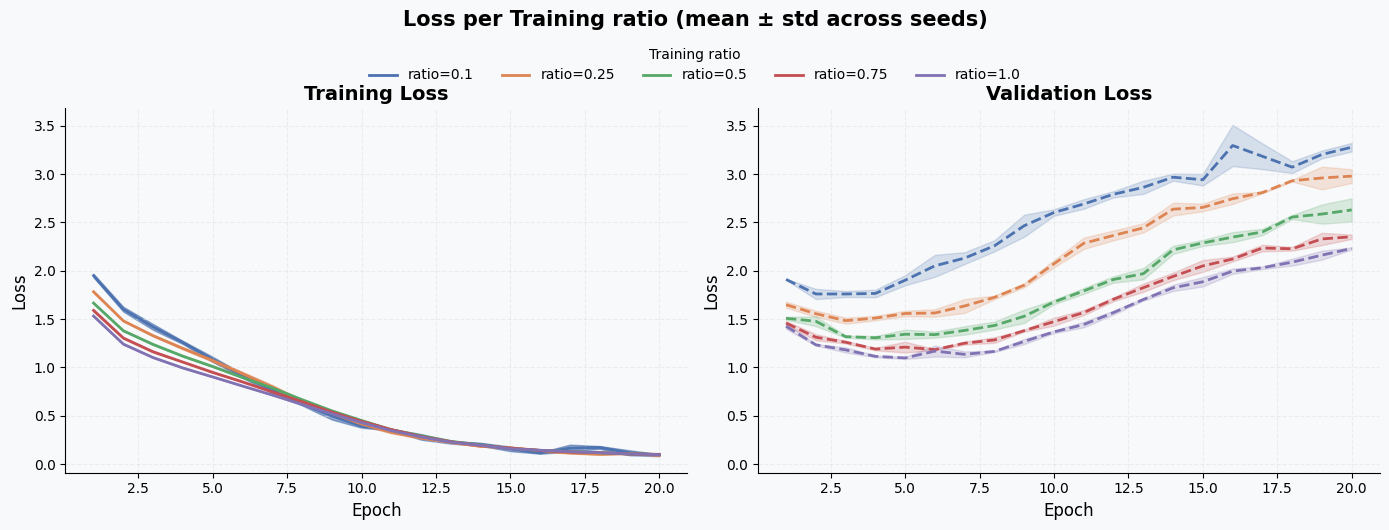

In [ ]:
plot_loss_comparison(resnet_results, param_name="Training ratio", param_name_short = 'ratio')

In [31]:
for param, seed_dict in resnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.1 | seeds=3 | max std=0.037605
lr=0.25 | seeds=3 | max std=0.022983
lr=0.5 | seeds=3 | max std=0.008100
lr=0.75 | seeds=3 | max std=0.010259
lr=1.0 | seeds=3 | max std=0.004441


In [32]:
df = summarize_results(resnet_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.10,0.417259,0.006759,3.279065,0.044245,0.417770,0.007199,3.284787,0.046242
1,Model,0.25,0.488541,0.003342,2.979982,0.071147,0.487000,0.003475,2.989394,0.070062
2,Model,0.50,0.551248,0.004892,2.630119,0.120540,0.552515,0.004412,2.630206,0.113069
3,Model,0.75,0.591552,0.003311,2.352502,0.022361,0.589978,0.003042,2.366801,0.012539
4,Model,1.00,0.610470,0.000152,2.231420,0.011308,0.609874,0.000777,2.242389,0.012255


In [33]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.10,0.4173 ± 0.0068,3.2791 ± 0.0442,0.4178 ± 0.0072,3.2848 ± 0.0462
1,Model,0.25,0.4885 ± 0.0033,2.9800 ± 0.0711,0.4870 ± 0.0035,2.9894 ± 0.0701
2,Model,0.50,0.5512 ± 0.0049,2.6301 ± 0.1205,0.5525 ± 0.0044,2.6302 ± 0.1131
3,Model,0.75,0.5916 ± 0.0033,2.3525 ± 0.0224,0.5900 ± 0.0030,2.3668 ± 0.0125
4,Model,1.00,0.6105 ± 0.0002,2.2314 ± 0.0113,0.6099 ± 0.0008,2.2424 ± 0.0123


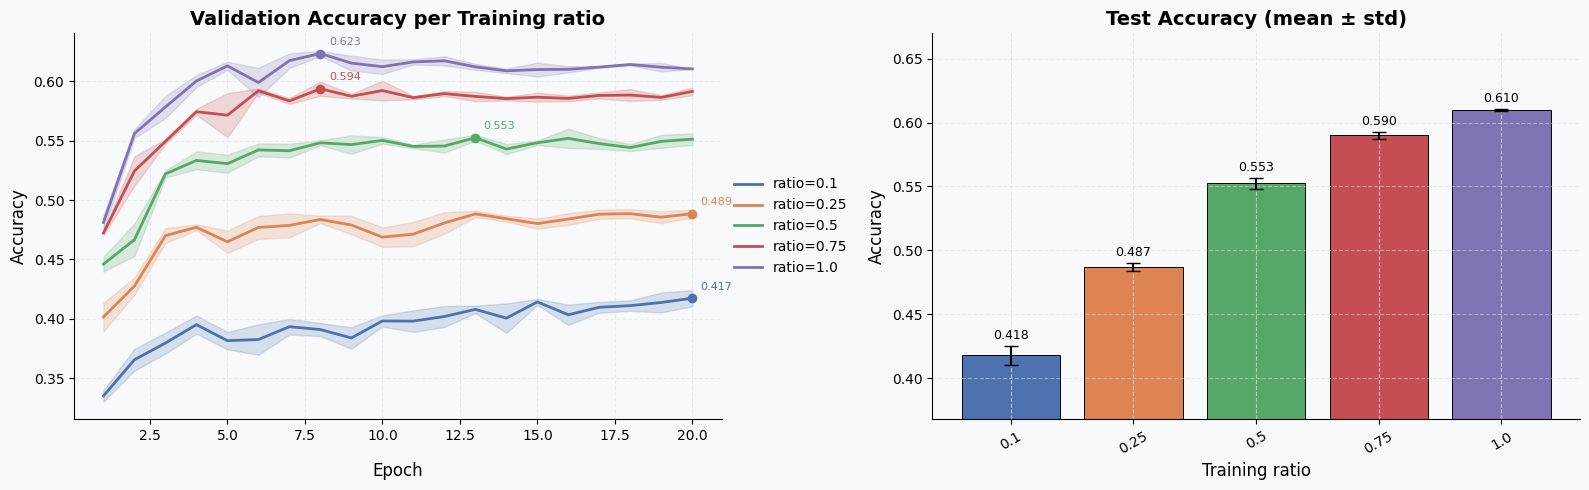

In [34]:
plot_accuracy_comparison(resnet_results, param_name="Training ratio", param_name_short = 'ratio')